# Notebook 5: Working with Data Like a Scientist

## Note

Notebooks 1–4 give you everything you need to build your own model. **This notebook is optional** — it is for students who want to go further.

The theme here is: *what do real scientists actually do with data?* You will learn to spot and fix data quality problems, extract seasonal patterns from long time series, compare datasets across different climate zones, and evaluate how well a model performs against observations. These are skills you will use every time you work with real environmental data.

## Learning Goals
- Detect and handle missing values (`NaN`) in real datasets
- Check whether data values are physically plausible
- Resample time series to different time scales (monthly, seasonal)
- Create multi-panel figures and dual-axis plots
- Quantify model performance with RMSE, bias, and correlation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

---
## 1. Real-World Data Challenges

Real datasets are messy. Before analysing anything you should always ask:
1. Are there **missing values**? Where, and how many?
2. Are all values **physically plausible**? (negative precipitation is impossible, for example)

### 1.1 Missing Values (NaN)

Python uses `NaN` (Not a Number) as a placeholder for missing data. Most pandas operations silently skip NaN, but some do not — so it is worth knowing exactly where your gaps are before you start.

In [2]:
# Load the Sweden dataset and check for missing values
data_sweden = pd.read_csv('../data/Data_swbm_Sweden.csv')

print("Dataset shape:", data_sweden.shape)
print("\nMissing values per column:")
print(data_sweden.isna().sum())

Dataset shape: (4018, 12)

Missing values per column:
time             0
longitude        0
latitude         0
snr_[MJ/m2]      0
tp_[mm]          0
ro_[m]           0
sm_[m3/m3]       0
le_[W/m2]        0
t2m_[K]          0
lai_[m2/m2]     28
evi_[]         682
ndvi_[]        682
dtype: int64


In [3]:
# Find exactly which rows have missing EVI values
nan_rows = data_sweden[data_sweden['evi_[]'].isna()]

print(f"Rows with missing EVI: {len(nan_rows)}")
print(f"  First missing date: {nan_rows['time'].iloc[0]}")
print(f"  Last missing date:  {nan_rows['time'].iloc[-1]}")
print()
print("Snapshot around the gap:")
print(data_sweden[['time', 'evi_[]', 'ndvi_[]']].iloc[12:22].to_string(index=False))

Rows with missing EVI: 682
  First missing date: 2008-01-01
  Last missing date:  2018-12-31

Snapshot around the gap:
      time   evi_[]  ndvi_[]
2008-01-13      NaN      NaN
2008-01-14      NaN      NaN
2008-01-15      NaN      NaN
2008-01-16      NaN      NaN
2008-01-17 0.200706 0.093611
2008-01-18 0.195636 0.097313
2008-01-19 0.190567 0.101015
2008-01-20 0.185497 0.104717
2008-01-21 0.180427 0.108420
2008-01-22 0.175357 0.112122


There are three common strategies for handling NaN. The right choice depends on how many values are missing and why:

| Strategy | When to use |
|----------|-------------|
| **Drop rows** | Few missing rows, you do not need them |
| **Fill with mean** | Short random gaps, values are roughly constant |
| **Backward fill** | NaN at the *start* of the series — use the next available value |

In [4]:
# Strategy 1: Drop rows that contain NaN in specific columns
data_dropped = data_sweden.dropna(subset=['evi_[]', 'ndvi_[]'])
print(f"Strategy 1 – Drop rows:")
print(f"  {len(data_sweden)} rows → {len(data_dropped)} rows after drop")

# Strategy 2: Fill with column mean
data_mean_filled = data_sweden.copy()
evi_mean = data_mean_filled['evi_[]'].mean()
data_mean_filled['evi_[]'] = data_mean_filled['evi_[]'].fillna(evi_mean)
print(f"\nStrategy 2 – Fill with mean ({evi_mean:.4f}):")
print(f"  NaN remaining: {data_mean_filled['evi_[]'].isna().sum()}")

# Strategy 3: Backward fill (use the next available value)
# Useful when NaN appears at the start of a series (no previous value to fill from)
data_bfilled = data_sweden.copy()
data_bfilled['evi_[]'] = data_bfilled['evi_[]'].bfill()
data_bfilled['ndvi_[]'] = data_bfilled['ndvi_[]'].bfill()
print(f"\nStrategy 3 – Backward fill:")
print(f"  NaN remaining in EVI:  {data_bfilled['evi_[]'].isna().sum()}")
print(f"  NaN remaining in NDVI: {data_bfilled['ndvi_[]'].isna().sum()}")

Strategy 1 – Drop rows:
  4018 rows → 3336 rows after drop

Strategy 2 – Fill with mean (0.2581):
  NaN remaining: 0

Strategy 3 – Backward fill:
  NaN remaining in EVI:  46
  NaN remaining in NDVI: 46


### 1.2 Plausibility Checks

Even when no values are marked as NaN, data can still contain errors. Always check that values fall within physically meaningful ranges.

In [5]:
print("Plausibility checks for the Sweden dataset:\n")

checks = {
    'Precipitation (tp_[mm]) >= 0': (data_sweden['tp_[mm]'] < 0).sum(),
    'Soil moisture in [0, 1] m3/m3': (
        (data_sweden['sm_[m3/m3]'] < 0) | (data_sweden['sm_[m3/m3]'] > 1)
    ).sum(),
    'Temperature (t2m_[K]) > 200 K': (data_sweden['t2m_[K]'] < 200).sum(),
}

for check, n_violations in checks.items():
    status = '  OK' if n_violations == 0 else f'  {n_violations} violations!'
    print(f"  {check}: {status}")

print("\nValue ranges:")
for col in ['tp_[mm]', 'sm_[m3/m3]', 't2m_[K]']:
    print(f"  {col}: {data_sweden[col].min():.3f} to {data_sweden[col].max():.3f}")

Plausibility checks for the Sweden dataset:

  Precipitation (tp_[mm]) >= 0:   53 violations!
  Soil moisture in [0, 1] m3/m3:   OK
  Temperature (t2m_[K]) > 200 K:   OK

Value ranges:
  tp_[mm]: -0.000 to 40.193
  sm_[m3/m3]: 0.257 to 0.451
  t2m_[K]: 243.253 to 296.421


---
## 2. Time Series Analysis

Daily data is often noisy. Resampling to monthly or seasonal averages reveals longer-term patterns that are impossible to see in the raw data.

The key tool is telling pandas that a column contains *dates*, not just strings. Once it knows that, it can group and resample by year, month, season, etc.

In [6]:
# Load Germany data and set the time column as the index
data_germany = pd.read_csv('../data/Data_swbm_Germany.csv')
data_germany['time'] = pd.to_datetime(data_germany['time'])   # convert string → date
data_germany = data_germany.set_index('time')                 # use date as row label

print("Date range:", data_germany.index.min().date(), "to", data_germany.index.max().date())
print("Total days:", len(data_germany))
print()
print(data_germany[['tp_[mm]', 'sm_[m3/m3]', 't2m_[K]']].head())

Date range: 2008-01-01 to 2018-12-31
Total days: 4018

              tp_[mm]  sm_[m3/m3]    t2m_[K]
time                                        
2008-01-01   0.008255    0.378376  271.58612
2008-01-02   0.002501    0.374456  269.07013
2008-01-03   0.013233    0.370631  271.70096
2008-01-04   0.000887    0.368569  272.94614
2008-01-05  12.935702    0.385177  278.24106


In [7]:
# resample('ME') groups all days in each month and applies an aggregation function
# Use .sum() for precipitation (total rain per month)
# Use .mean() for soil moisture (average state per month)
monthly_precip = data_germany['tp_[mm]'].resample('ME').sum()
monthly_sm = data_germany['sm_[m3/m3]'].resample('ME').mean()

print("Monthly total precipitation – first 12 months:")
for date, val in monthly_precip.head(12).items():
    print(f"  {date.strftime('%Y-%m')}: {val:6.1f} mm")

print(f"\nWettest month: {monthly_precip.idxmax().strftime('%Y-%m')} ({monthly_precip.max():.1f} mm)")
print(f"Driest month:  {monthly_precip.idxmin().strftime('%Y-%m')} ({monthly_precip.min():.1f} mm)")

Monthly total precipitation – first 12 months:
  2008-01:   85.1 mm
  2008-02:   57.5 mm
  2008-03:  157.0 mm
  2008-04:  144.6 mm
  2008-05:   80.8 mm
  2008-06:  129.8 mm
  2008-07:  106.3 mm
  2008-08:  105.5 mm
  2008-09:   76.4 mm
  2008-10:  150.4 mm
  2008-11:   63.1 mm
  2008-12:  113.8 mm

Wettest month: 2014-07 (324.8 mm)
Driest month:  2011-11 (5.3 mm)


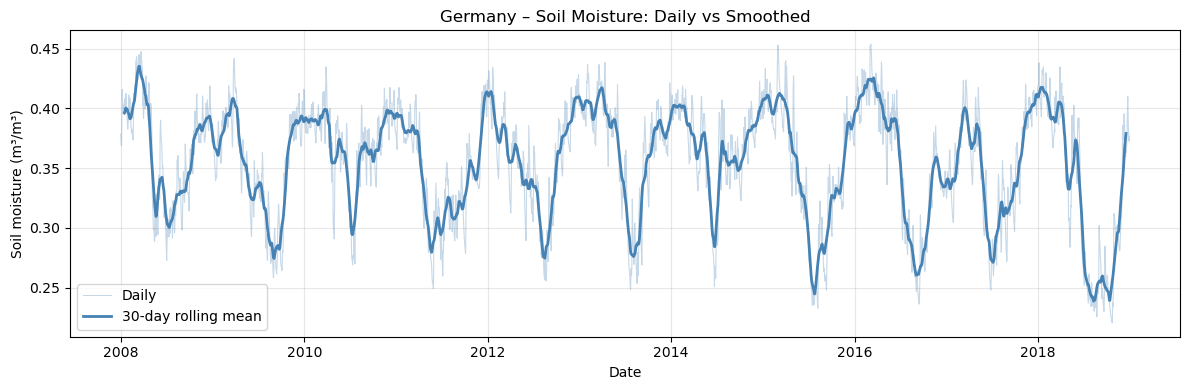

In [8]:
# A rolling mean smooths out short-term noise while keeping the trend
rolling_sm = data_germany['sm_[m3/m3]'].rolling(window=30, center=True).mean()

plt.figure(figsize=(12, 4))
plt.plot(data_germany.index, data_germany['sm_[m3/m3]'],
         alpha=0.3, linewidth=0.8, color='steelblue', label='Daily')
plt.plot(data_germany.index, rolling_sm,
         linewidth=2, color='steelblue', label='30-day rolling mean')
plt.xlabel('Date')
plt.ylabel('Soil moisture (m\u00b3/m\u00b3)')
plt.title('Germany \u2013 Soil Moisture: Daily vs Smoothed')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

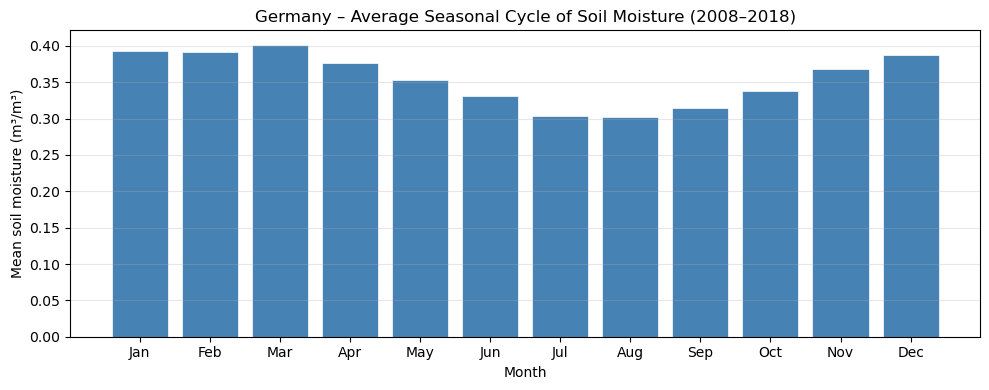

Highest soil moisture: Mar
Lowest soil moisture:  Aug


In [9]:
# Average over all years by calendar month to get the typical seasonal cycle
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

seasonal_sm = data_germany.groupby(data_germany.index.month)['sm_[m3/m3]'].mean()

plt.figure(figsize=(10, 4))
plt.bar(month_names, seasonal_sm.values, color='steelblue', edgecolor='white', linewidth=0.5)
plt.xlabel('Month')
plt.ylabel('Mean soil moisture (m\u00b3/m\u00b3)')
plt.title('Germany \u2013 Average Seasonal Cycle of Soil Moisture (2008\u20132018)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Highest soil moisture: {month_names[seasonal_sm.idxmax() - 1]}")
print(f"Lowest soil moisture:  {month_names[seasonal_sm.idxmin() - 1]}")

---
## 3. Comparing Multiple Datasets

The three datasets cover very different climates: central Europe (Germany), Mediterranean (Spain), and sub-arctic (Sweden). Plotting them together reveals how climate shapes the water cycle.

Here we also introduce two plotting techniques that are useful whenever you have two variables with different units: **multi-panel figures** and **dual y-axes**.

In [10]:
# Load all three datasets
countries = {}
for name, filename in [('Germany', 'Data_swbm_Germany.csv'),
                        ('Spain',   'Data_swbm_Spain.csv'),
                        ('Sweden',  'Data_swbm_Sweden.csv')]:
    df = pd.read_csv(f'../data/{filename}')
    df['time'] = pd.to_datetime(df['time'])
    df = df.set_index('time')
    countries[name] = df

print("Loaded datasets:")
for name, df in countries.items():
    print(f"  {name:8s}: avg precip = {df['tp_[mm]'].mean():.2f} mm/day,  "
          f"avg soil moisture = {df['sm_[m3/m3]'].mean():.3f} m\u00b3/m\u00b3")

Loaded datasets:
  Germany : avg precip = 3.35 mm/day,  avg soil moisture = 0.355 m³/m³
  Spain   : avg precip = 1.35 mm/day,  avg soil moisture = 0.224 m³/m³
  Sweden  : avg precip = 1.96 mm/day,  avg soil moisture = 0.369 m³/m³


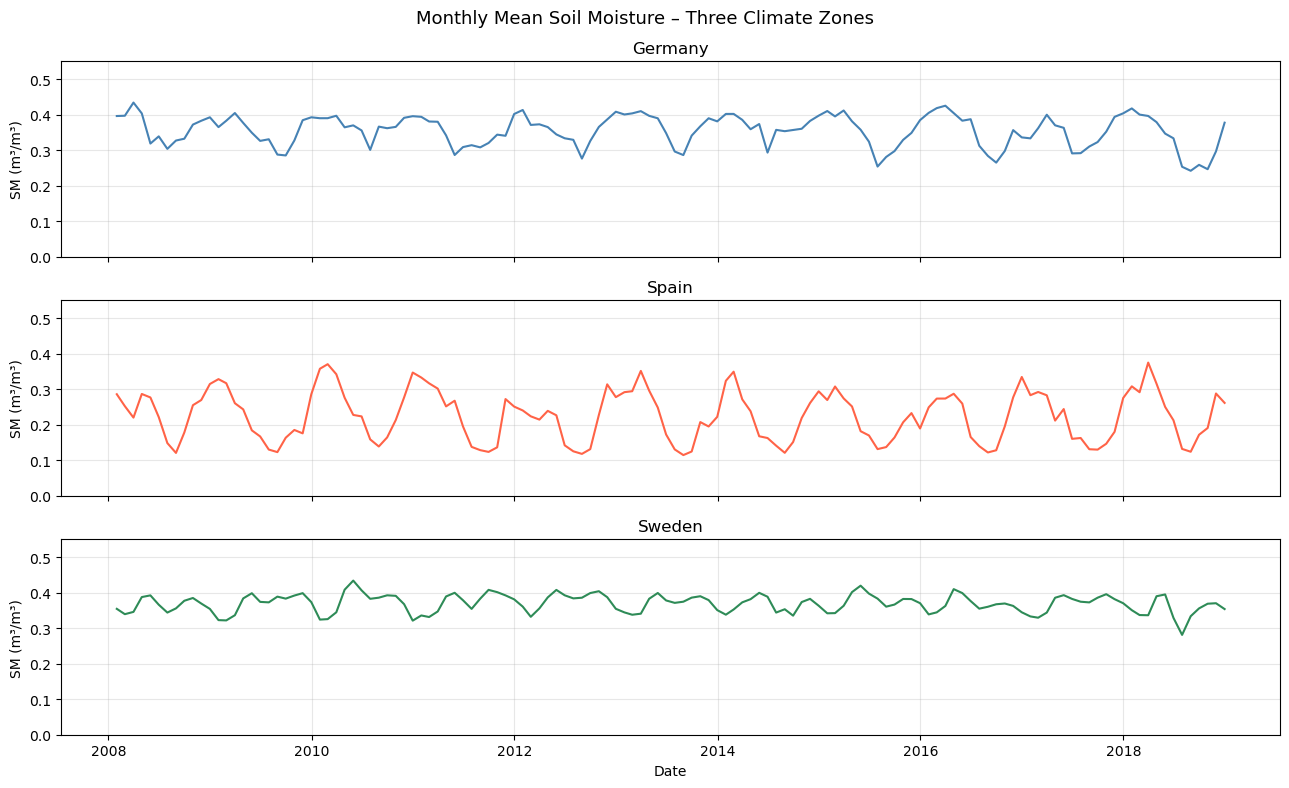

Things to notice:
  - Which country has the highest soil moisture, and why?
  - Which shows the strongest seasonal cycle?
  - What drives the very low summer values in Spain?


In [11]:
# Multi-panel figure: one panel per country, shared x-axis
colors = {'Germany': 'steelblue', 'Spain': 'tomato', 'Sweden': 'seagreen'}

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

for ax, (name, df) in zip(axes, countries.items()):
    monthly_sm = df['sm_[m3/m3]'].resample('ME').mean()
    ax.plot(monthly_sm.index, monthly_sm, color=colors[name], linewidth=1.5)
    ax.set_ylabel('SM (m\u00b3/m\u00b3)')
    ax.set_title(name)
    ax.set_ylim(0, 0.55)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Date')
fig.suptitle('Monthly Mean Soil Moisture \u2013 Three Climate Zones', fontsize=13)
plt.tight_layout()
plt.show()

print("Things to notice:")
print("  - Which country has the highest soil moisture, and why?")
print("  - Which shows the strongest seasonal cycle?")
print("  - What drives the very low summer values in Spain?")

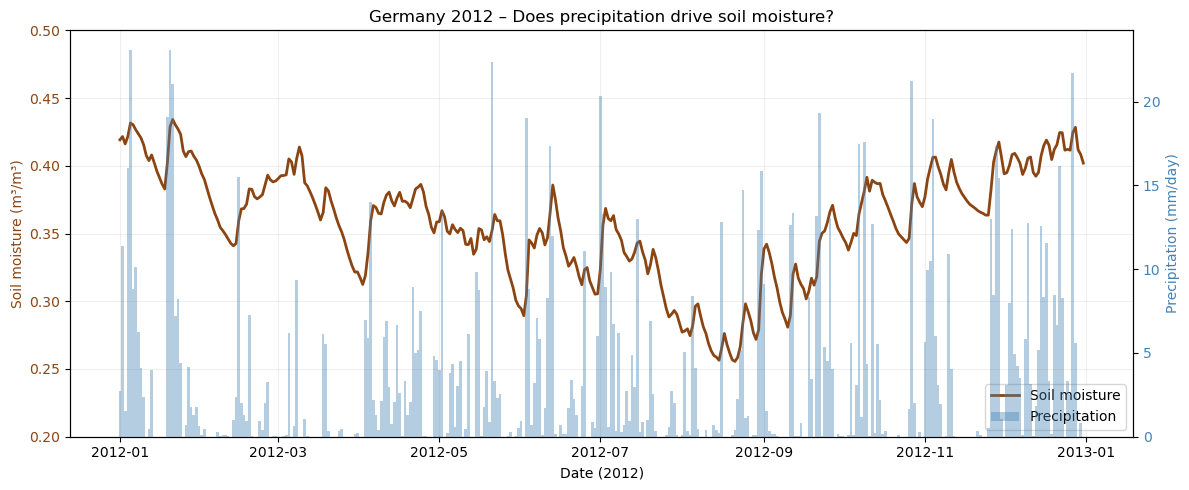

In [12]:
# Dual y-axis: show precipitation and soil moisture together for one year
# Two variables with very different units on the same plot
year_data = countries['Germany'].loc['2012']

fig, ax1 = plt.subplots(figsize=(12, 5))

# Left axis: soil moisture
ax1.plot(year_data.index, year_data['sm_[m3/m3]'],
         color='saddlebrown', linewidth=2, label='Soil moisture')
ax1.set_ylabel('Soil moisture (m\u00b3/m\u00b3)', color='saddlebrown')
ax1.tick_params(axis='y', labelcolor='saddlebrown')
ax1.set_ylim(0.2, 0.5)

# Right axis: precipitation (twinx creates a second y-axis sharing the same x-axis)
ax2 = ax1.twinx()
ax2.bar(year_data.index, year_data['tp_[mm]'],
        color='steelblue', alpha=0.4, width=1, label='Precipitation')
ax2.set_ylabel('Precipitation (mm/day)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax1.set_xlabel('Date (2012)')
ax1.set_title('Germany 2012 \u2013 Does precipitation drive soil moisture?')
ax1.grid(alpha=0.2)

# Merge the two legends into one
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.tight_layout()
plt.show()

---
## 4. Evaluating a Model

After you build a model, the natural question is: **how good is it?** Saying "the time series looks reasonable" is not enough — you need numbers.

Three metrics cover the most important aspects of model performance:

| Metric | Formula | What it tells you |
|--------|---------|-------------------|
| **RMSE** | $\sqrt{\frac{1}{n}\sum(obs - pred)^2}$ | Typical error size (same units as data) |
| **Bias** | $\frac{1}{n}\sum(pred - obs)$ | Systematic over- or under-estimation |
| **Correlation** | $r(obs, pred)$ | Does the model capture the right timing and shape? |

We will use the **plant growth model from Notebook 4** to demonstrate these. The key idea: we create synthetic "observations" (model output + realistic noise) and then check how well two different parameter choices recover the signal.

In [13]:
# Plant growth model from Notebook 4 (condensed for reference)

def temperature_limitation(temp, optimal_temp, temp_range):
    temp_stress = abs(temp - optimal_temp) / temp_range
    return max(0.0, 1 - temp_stress ** 2)

def water_limitation(rainfall, water_demand):
    return min(rainfall / water_demand, 1.0)

def run_plant_model(params, temperatures, rainfalls):
    """Run the plant growth model and return the full biomass time series."""
    n = len(temperatures)
    biomass = np.zeros(n + 1)
    biomass[0] = 50.0  # g/m2 (seedling)

    for day in range(n):
        tf = temperature_limitation(temperatures[day], params['optimal_temp'], params['temp_range'])
        wf = water_limitation(rainfalls[day], params['water_demand'])
        space = 1 - (biomass[day] / params['max_biomass'])
        growth = biomass[day] * params['max_growth_rate'] * tf * wf * space
        biomass[day + 1] = biomass[day] + growth

    return biomass

print("Plant model ready.")

Plant model ready.


In [14]:
# Create synthetic driving data and "observations"
np.random.seed(42)
n_days = 100
temperatures = 15 + 10 * np.sin(np.arange(n_days) / n_days * 2 * np.pi)
rainfalls = np.random.gamma(shape=2, scale=5, size=n_days)

# The "true" parameter set (unknown to us in practice)
params_true = {
    'max_growth_rate': 0.02,
    'optimal_temp':    20,
    'temp_range':      10,
    'water_demand':    50,
    'max_biomass':     2000
}

# Observations = true model run + measurement noise
biomass_true = run_plant_model(params_true, temperatures, rainfalls)
observations = biomass_true + np.random.normal(0, 15, len(biomass_true))
observations = np.maximum(observations, 0)  # biomass can't go negative

print("Synthetic observations created.")
print(f"Observed biomass range: {observations.min():.1f} \u2013 {observations.max():.1f} g/m\u00b2")
print()
print("Imagine: you measured plant biomass in the field for 100 days.")
print("Now you want to know: how well does your model reproduce these measurements?")

Synthetic observations created.
Observed biomass range: 11.7 – 115.6 g/m²

Imagine: you measured plant biomass in the field for 100 days.
Now you want to know: how well does your model reproduce these measurements?


In [15]:
# Define the three evaluation metrics
def rmse(observed, predicted):
    return np.sqrt(np.mean((observed - predicted) ** 2))

def bias(observed, predicted):
    return np.mean(predicted - observed)

def correlation(observed, predicted):
    return np.corrcoef(observed, predicted)[0, 1]

# Compare two parameter sets
params_a = params_true.copy()                  # close to truth

params_b = params_true.copy()
params_b['max_growth_rate'] = 0.03             # too high: model will overshoot

print(f"{'Model':<35} {'RMSE':>8} {'Bias':>8} {'Corr':>8}")
print("-" * 62)
for label, params in [('Model A  (growth_rate = 0.02)', params_a),
                       ('Model B  (growth_rate = 0.03)', params_b)]:
    preds = run_plant_model(params, temperatures, rainfalls)
    r = rmse(observations, preds)
    b = bias(observations, preds)
    c = correlation(observations, preds)
    print(f"{label:<35} {r:>7.1f}g {b:>+8.1f}g {c:>8.3f}")

Model                                   RMSE     Bias     Corr
--------------------------------------------------------------
Model A  (growth_rate = 0.02)          16.0g     -1.1g    0.113
Model B  (growth_rate = 0.03)          16.5g     +2.8g    0.113


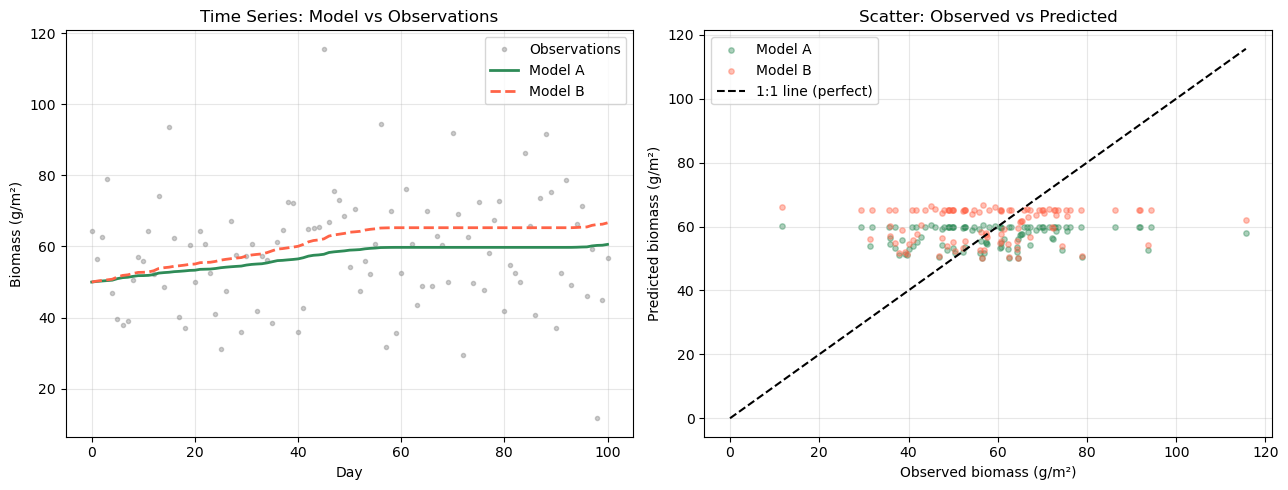

The 1:1 line is your reference: a perfect model has all points on this line.
Points above the line → model over-predicts.
Points below the line → model under-predicts.


In [16]:
preds_a = run_plant_model(params_a, temperatures, rainfalls)
preds_b = run_plant_model(params_b, temperatures, rainfalls)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: time series
axes[0].plot(observations, 'o', markersize=3, alpha=0.4, color='gray', label='Observations')
axes[0].plot(preds_a, linewidth=2, color='seagreen', label='Model A')
axes[0].plot(preds_b, linewidth=2, color='tomato', linestyle='--', label='Model B')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Biomass (g/m\u00b2)')
axes[0].set_title('Time Series: Model vs Observations')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: scatter plot (the "1:1 line" is the gold standard)
max_val = max(observations.max(), preds_b.max())
axes[1].scatter(observations, preds_a, alpha=0.4, s=15, color='seagreen', label='Model A')
axes[1].scatter(observations, preds_b, alpha=0.4, s=15, color='tomato',   label='Model B')
axes[1].plot([0, max_val], [0, max_val], 'k--', linewidth=1.5, label='1:1 line (perfect)')
axes[1].set_xlabel('Observed biomass (g/m\u00b2)')
axes[1].set_ylabel('Predicted biomass (g/m\u00b2)')
axes[1].set_title('Scatter: Observed vs Predicted')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("The 1:1 line is your reference: a perfect model has all points on this line.")
print("Points above the line → model over-predicts.")
print("Points below the line → model under-predicts.")

---
## Exercises

### Exercise 1: Data quality investigation

Load the Spain dataset and carry out a full data quality check:
- How many missing values are there in each column?
- Are all precipitation values non-negative?
- What is the temperature range (in Kelvin and in Celsius)? Does it seem realistic for Spain?

If you find any issues, decide which strategy would be most appropriate to handle them.

In [ ]:
# YOUR CODE HERE
# data_spain = pd.read_csv('../data/Data_swbm_Spain.csv')
# ...

### Exercise 2: Seasonal precipitation comparison

Create a figure with three bar charts (one per country) showing the **average monthly total precipitation** — the seasonal cycle of rainfall.

- Which country has the most pronounced dry season?
- In which months does each country receive most of its rain?
- What does this tell you about how soil moisture might behave differently across the three sites?

In [ ]:
# YOUR CODE HERE
# Hint: use groupby(df.index.month) on each country's data
# Hint: use resample('ME').sum() first, then groupby month to average across years
# ...

### Exercise 3: Find better parameters

The `observations` and helper functions from Section 4 are still in memory. Your task is to find a parameter set that achieves a **lower RMSE than Model A**.

Try changing one parameter at a time. For each attempt, print the RMSE, bias, and correlation. Which parameter has the biggest effect on RMSE? Which has the biggest effect on bias?

In [ ]:
# YOUR CODE HERE
# params_mine = {
#     'max_growth_rate': ???,
#     'optimal_temp':    ???,
#     'temp_range':      ???,
#     'water_demand':    ???,
#     'max_biomass':     ???
# }
# preds_mine = run_plant_model(params_mine, temperatures, rainfalls)
# print(f"RMSE: {rmse(observations, preds_mine):.1f} g/m\u00b2")
# print(f"Bias: {bias(observations, preds_mine):+.1f} g/m\u00b2")
# print(f"Corr: {correlation(observations, preds_mine):.3f}")